In [14]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from joblib import Parallel, delayed
import Conor as c


In [15]:
def compute_regret_slopes(results, scalings, v_star, fit_start=500):
    """Fit log-log regret slope for each scaling. Returns DataFrame + regret dict."""
    records, regret_dict = [], {}
    for s in scalings:
        label   = f'scaling={s}'
        vpi     = results[label]['vpi']
        eps     = np.arange(1, len(vpi) + 1)
        cum_reg = np.cumsum(np.maximum(v_star - vpi, 0.0))
        regret_dict[label] = cum_reg
        mask = (eps >= fit_start) & (cum_reg > 0)
        if mask.sum() < 10:
            records.append({'scaling': s, 'alpha': float('nan'), 'r_squared': float('nan')})
            continue
        slope, _, r, _, _ = stats.linregress(np.log(eps[mask]), np.log(cum_reg[mask]))
        records.append({'scaling': s, 'alpha': round(slope, 4), 'r_squared': round(r**2, 4)})
    return pd.DataFrame(records), regret_dict


# Reward 1 — asymmetric quadratic

In [16]:
importlib.reload(c)

cfg_r1 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quadratic_asymmetric,
)
solver_r1 = c.BellmanSolverScalar(cfg_r1, n_state=201, n_action=201, n_quad=41)
solver_r1.solve()
V_STAR_R1 = solver_r1.get_value(cfg_r1.starting_state)
print(f'V*(x0) = {V_STAR_R1:.4f}  (expected ≈ 0.0)')


V*(x0) = 0.0005  (expected ≈ 0.0)


In [17]:
scalings_r1 = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in scalings_r1
]
results_sweep_r1 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.01 ---
    Done. Final mean VPI: -36.691

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -38.130

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -36.602

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -29.466

--- Running: scaling=1 ---
    Done. Final mean VPI: -22.711

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.914

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.800

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.465

--- Running: scaling=100 ---
    Done. Final mean VPI: -99.478

--- Running: scaling=500 ---
    Done. Final mean VPI: -150.571


In [18]:
summary_r1 = []
for s in scalings_r1:
    label = f'scaling={s}'
    vpi  = results_sweep_r1[label]['vpi']
    arms = results_sweep_r1[label]['arms']
    summary_r1.append({
        'scaling': s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })
summary_df_r1 = pd.DataFrame(summary_r1)
summary_df_r1


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-72728.664952,-36.690547,218.5,218.104
1,0.05,-75230.403961,-38.129636,218.5,218.500
2,0.10,-72935.243199,-36.602215,217.3,217.300
3,0.50,-59336.689572,-29.466133,217.3,217.054
4,1.00,-46906.805749,-22.711171,218.5,218.497
5,5.00,-15114.464462,-3.914448,225.1,224.230
6,10.00,-13866.606993,-3.800484,220.3,217.837
7,50.00,-135941.104550,-59.465464,214.0,213.658
8,100.00,-217462.306074,-99.478403,211.6,210.394
9,500.00,-281225.084012,-150.571076,217.0,217.000


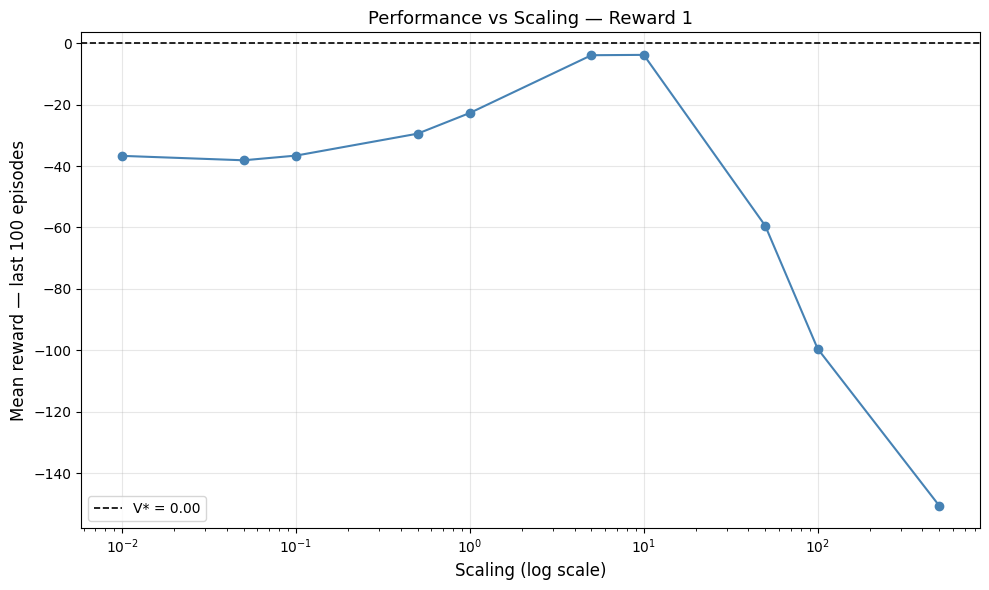

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r1['scaling'], summary_df_r1['late_mean_reward'], marker='o', color='steelblue', lw=1.5)
ax.axhline(V_STAR_R1, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R1:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs Scaling — Reward 1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_scaling_1.png', dpi=150, bbox_inches='tight')
plt.show()


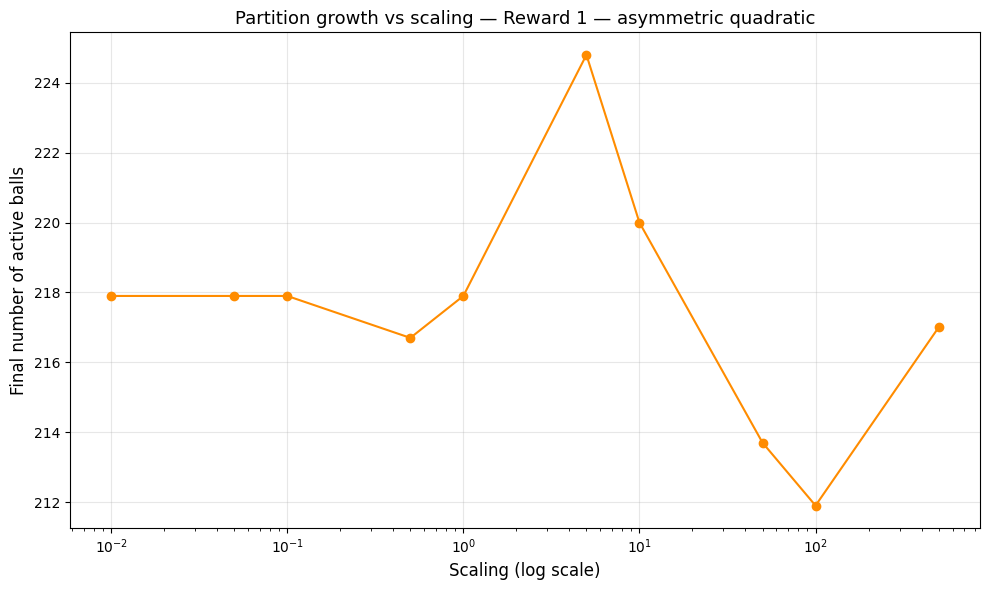

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r1['scaling'], summary_df_r1['final_arms'], marker='o', color='darkorange', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Final number of active balls', fontsize=12)
ax.set_title('Partition growth vs scaling — Reward 1 — asymmetric quadratic', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


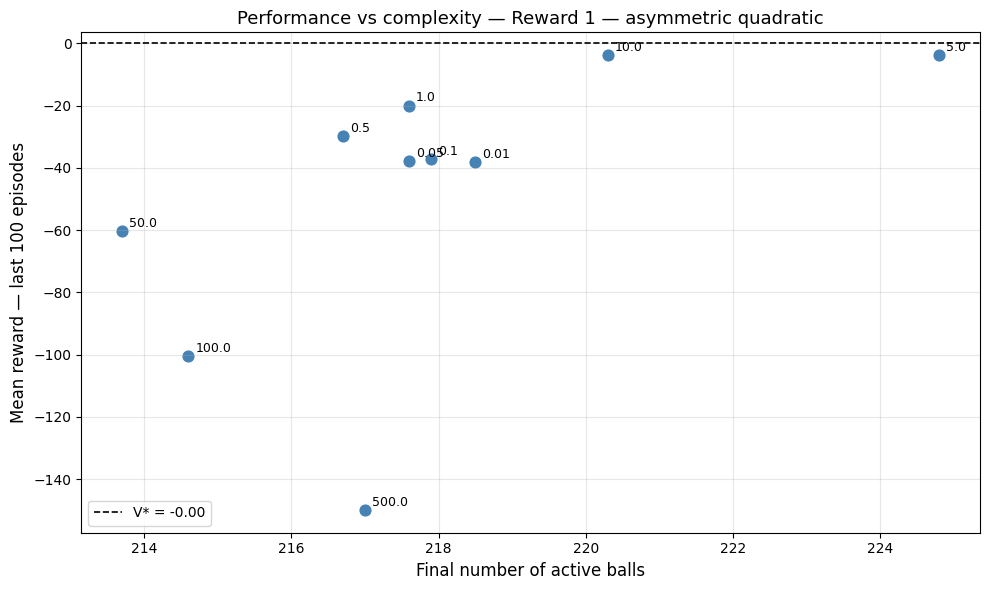

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary_df_r1['final_arms'], summary_df_r1['late_mean_reward'], color='steelblue', s=60)
for _, row in summary_df_r1.iterrows():
    ax.annotate(str(row['scaling']), (row['final_arms'], row['late_mean_reward']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.axhline(V_STAR_R1, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R1:.2f}')
ax.set_xlabel('Final number of active balls', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs complexity — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
chosen_scalings_r1 = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in chosen_scalings_r1
]
results_chosen_r1 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.275

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.874

--- Running: scaling=100 ---
    Done. Final mean VPI: -99.921


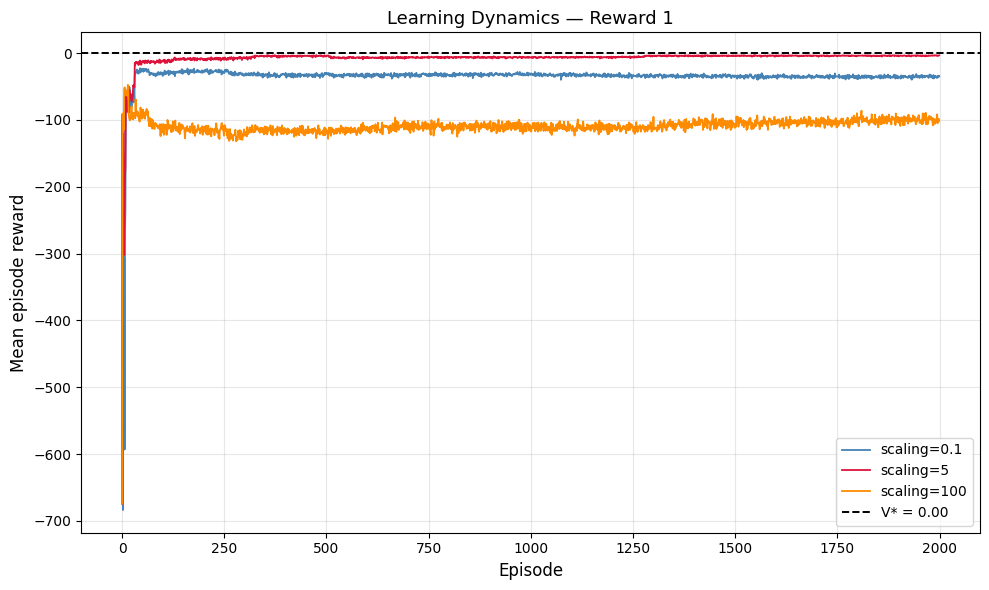

In [58]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r1:
    ax.plot(results_chosen_r1[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R1, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R1:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning Dynamics — Reward 1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_dynamics_1.png', dpi=150, bbox_inches='tight')
plt.show()


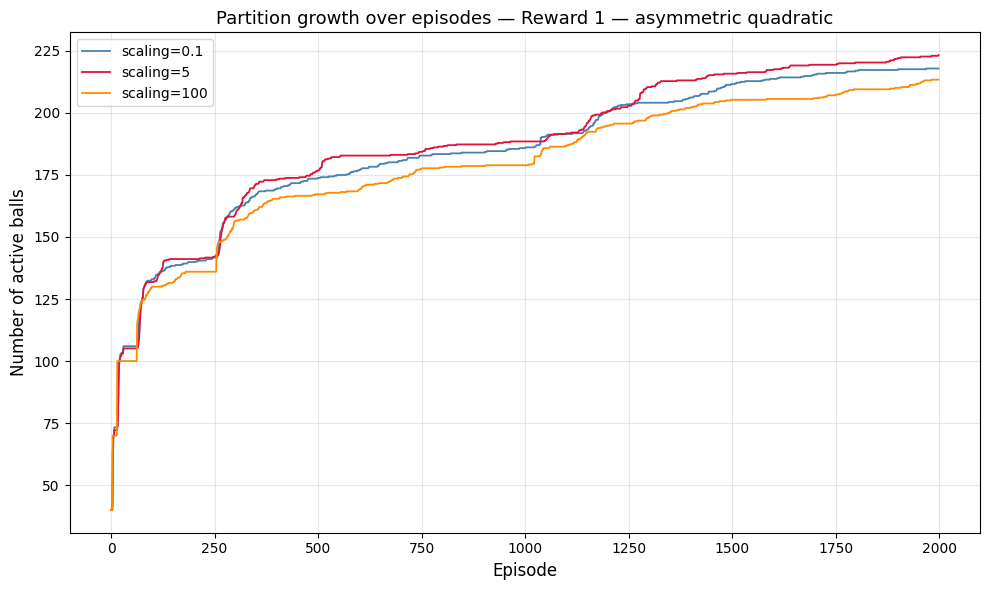

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r1:
    ax.plot(results_chosen_r1[f'scaling={s}']['arms'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Number of active balls', fontsize=12)
ax.set_title('Partition growth over episodes — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


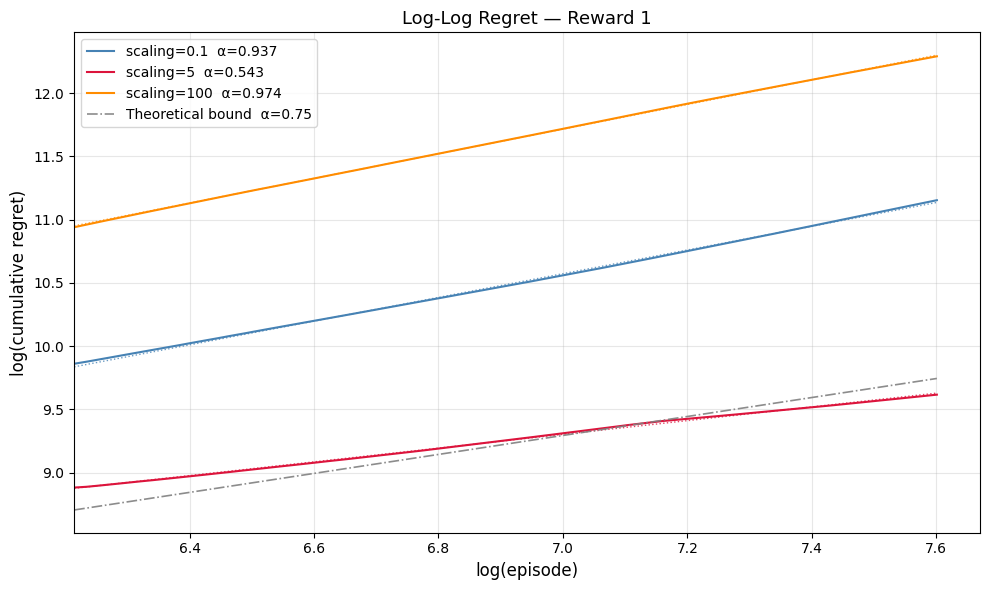

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in chosen_scalings_r1:
    vpi     = results_chosen_r1[f'scaling={s}']['vpi']
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R1 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.5, color=COLOURS[s], label=f'scaling={s}  α={slope:.3f}')
    ax.plot(lx, slope*lx + intercept, lw=1.0, color=COLOURS[s], ls=':', alpha=0.8)

# Theoretical worst-case bound α=0.75 anchored through midpoint of best curve
_best_vpi = results_chosen_r1['scaling=5']['vpi']
_eps      = np.arange(1, len(_best_vpi) + 1)
_cum      = np.cumsum(np.maximum(V_STAR_R1 - _best_vpi, 0.0))
_mask     = (_eps >= 500) & (_cum > 0)
_mid      = len(_eps[_mask]) // 2
_th_ic    = np.log(max(_cum[_mask][_mid], 1e-8)) - 0.75 * np.log(_eps[_mask][_mid])
_lx_th    = np.array([np.log(500), np.log(len(_best_vpi))])
ax.plot(_lx_th, 0.75*_lx_th + _th_ic, lw=1.2, color='gray', ls='-.', alpha=0.9,
        label='Theoretical bound  α=0.75')

ax.set_xlim(left=np.log(500))
ax.set_xlabel('log(episode)', fontsize=12)
ax.set_ylabel('log(cumulative regret)', fontsize=12)
ax.set_title('Log-Log Regret — Reward 1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 scaling  alpha  r_squared
    0.01 0.9385     0.9993
    0.05 0.9481     0.9992
    0.10 0.9445     0.9993
    0.50 0.9230     0.9993
    1.00 0.8742     0.9988
    5.00 0.5520     0.9978
   10.00 0.5726     0.9963
   50.00 0.8694     1.0000
  100.00 0.9706     0.9999
  500.00 1.0781     1.0000


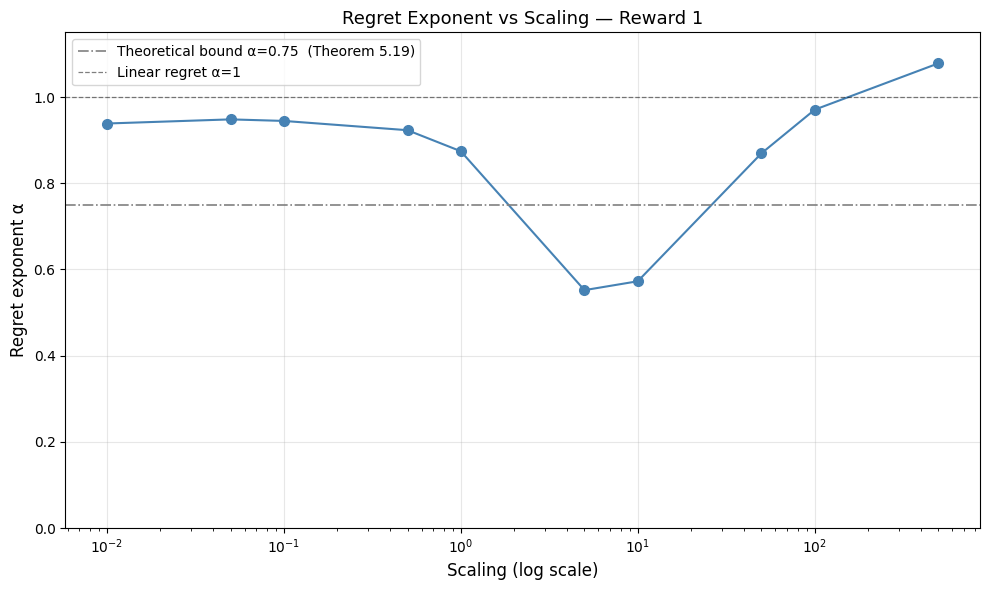

In [24]:
slopes_r1, regret_r1 = compute_regret_slopes(results_sweep_r1, scalings_r1, V_STAR_R1)
print(slopes_r1.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(slopes_r1['scaling'], slopes_r1['alpha'], marker='o', color='steelblue', lw=1.5, ms=7)
ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75  (Theorem 5.19)')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret Exponent vs Scaling — Reward 1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reward 2 — shifted quadratic

In [25]:
importlib.reload(c)

cfg_r2 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quadratic_shifted,
)
solver_r2 = c.BellmanSolverScalar(cfg_r2, n_state=201, n_action=201, n_quad=41)
solver_r2.solve()
V_STAR_R2 = solver_r2.get_value(cfg_r2.starting_state)
print(f'V*(x0) = {V_STAR_R2:.4f}  (expected ≈ 100.0)')


V*(x0) = 100.0057  (expected ≈ 100.0)


In [26]:
scalings_r2 = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in scalings_r2
]
results_sweep_r2 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.01 ---
    Done. Final mean VPI: 92.293

--- Running: scaling=0.05 ---
    Done. Final mean VPI: 92.922

--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.094

--- Running: scaling=0.5 ---
    Done. Final mean VPI: 95.218

--- Running: scaling=1 ---
    Done. Final mean VPI: 97.538

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.189

--- Running: scaling=10 ---
    Done. Final mean VPI: 83.566

--- Running: scaling=50 ---
    Done. Final mean VPI: 58.547

--- Running: scaling=100 ---
    Done. Final mean VPI: 45.482

--- Running: scaling=500 ---
    Done. Final mean VPI: 36.290


In [27]:
summary_r2 = []
for s in scalings_r2:
    label = f'scaling={s}'
    vpi  = results_sweep_r2[label]['vpi']
    arms = results_sweep_r2[label]['arms']
    summary_r2.append({
        'scaling': s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })
summary_df_r2 = pd.DataFrame(summary_r2)
summary_df_r2


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,185360.575142,92.293043,218.5,217.051
1,0.05,186201.804383,92.921635,219.4,217.606
2,0.10,186916.394022,93.094259,218.8,217.345
3,0.50,190421.681434,95.218332,220.0,218.881
4,1.00,193736.968592,97.538378,220.9,218.827
5,5.00,180924.396673,91.189389,208.3,208.171
6,10.00,164356.262338,83.566450,208.9,208.273
7,50.00,114373.261501,58.546973,211.3,211.240
8,100.00,91139.717552,45.481937,214.0,214.000
9,500.00,79717.546385,36.290100,217.0,217.000


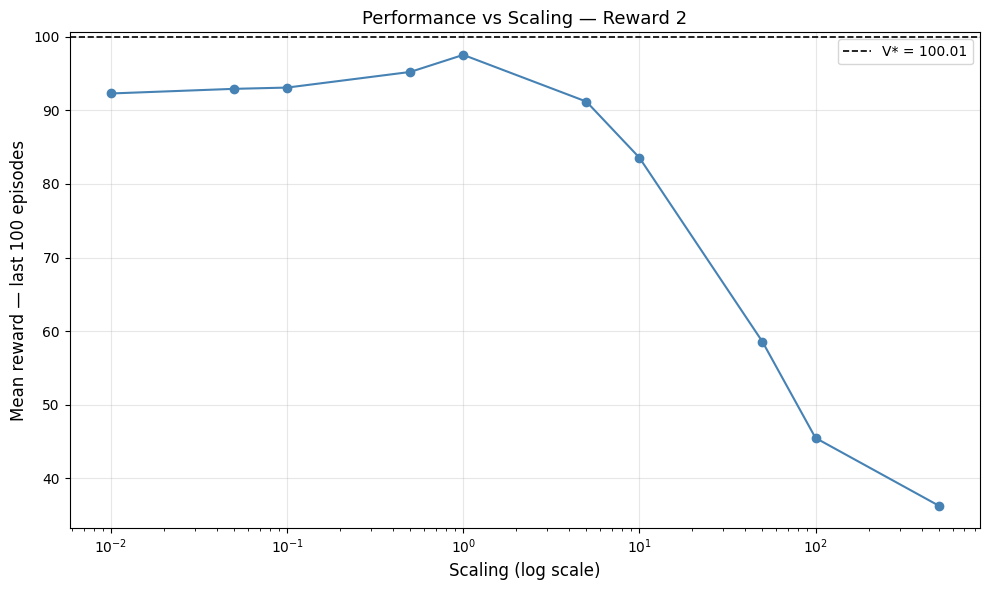

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r2['scaling'], summary_df_r2['late_mean_reward'], marker='o', color='steelblue', lw=1.5)
ax.axhline(V_STAR_R2, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R2:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs Scaling — Reward 2', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_scaling_2.png', dpi=150, bbox_inches='tight')
plt.show()


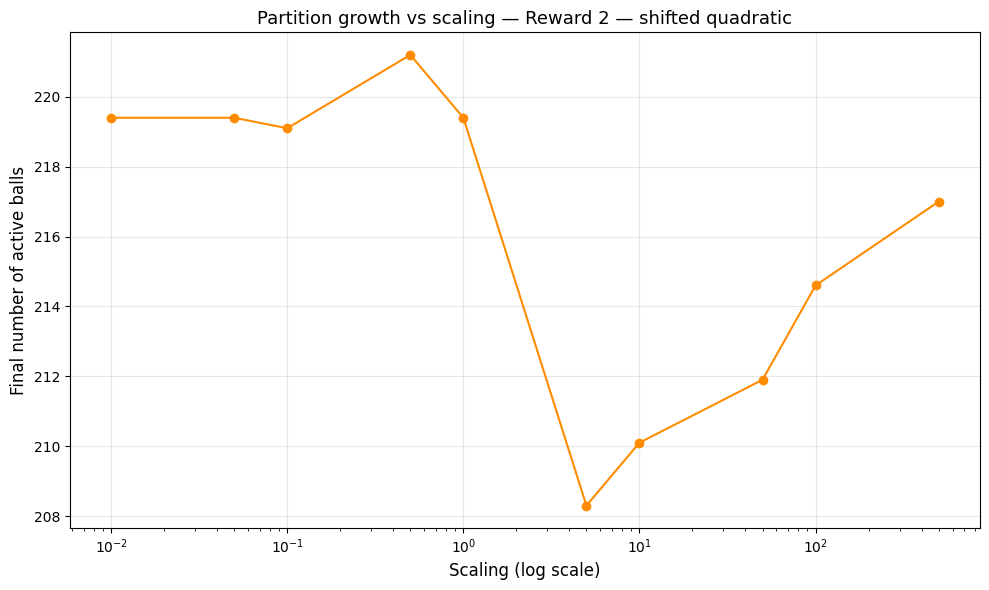

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r2['scaling'], summary_df_r2['final_arms'], marker='o', color='darkorange', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Final number of active balls', fontsize=12)
ax.set_title('Partition growth vs scaling — Reward 2 — shifted quadratic', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


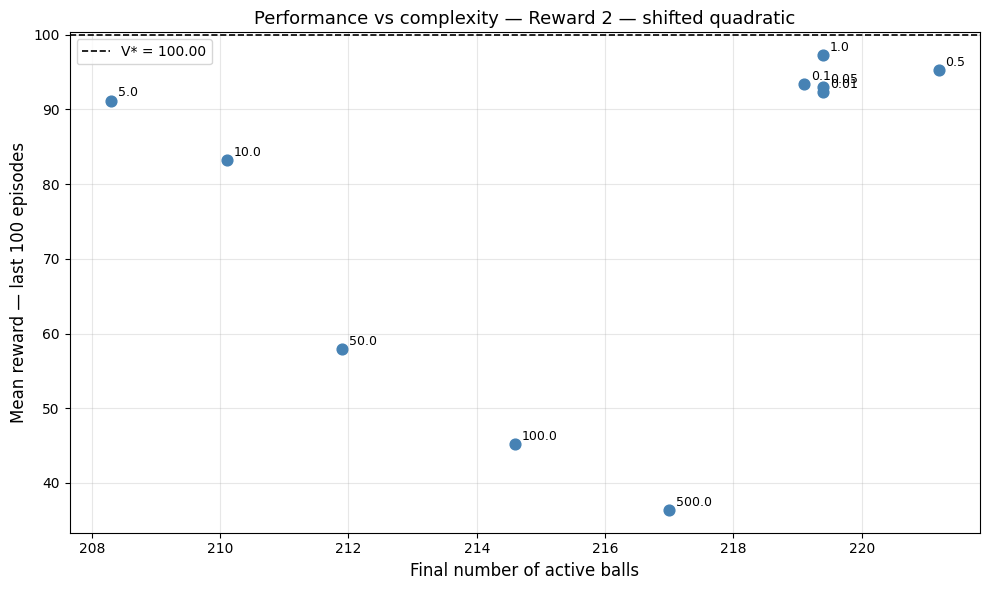

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary_df_r2['final_arms'], summary_df_r2['late_mean_reward'], color='steelblue', s=60)
for _, row in summary_df_r2.iterrows():
    ax.annotate(str(row['scaling']), (row['final_arms'], row['late_mean_reward']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.axhline(V_STAR_R2, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R2:.2f}')
ax.set_xlabel('Final number of active balls', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs complexity — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
chosen_scalings_r2 = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in chosen_scalings_r2
]
results_chosen_r2 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.478

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.382

--- Running: scaling=100 ---
    Done. Final mean VPI: 45.416


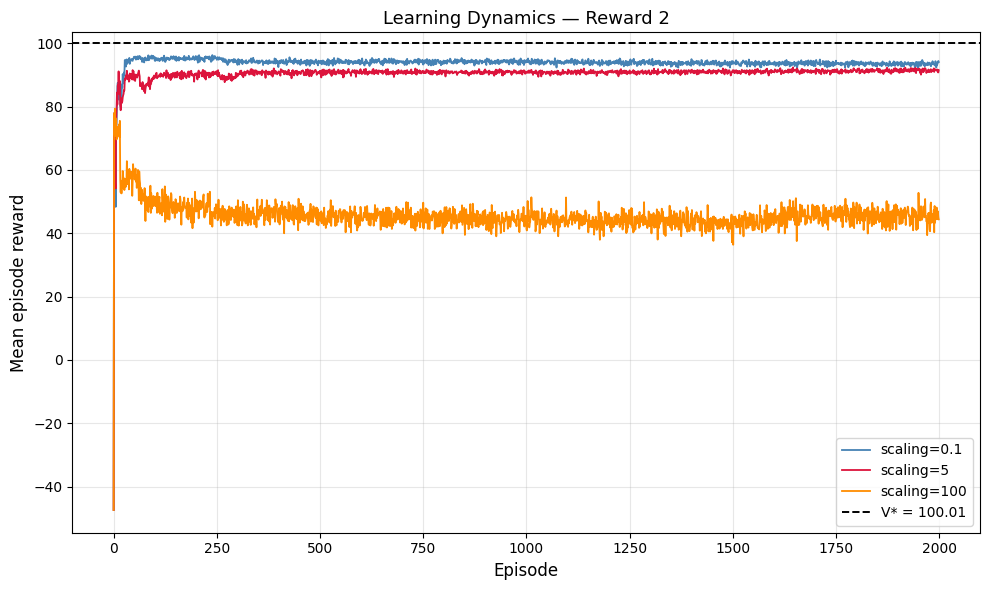

In [56]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r2:
    ax.plot(results_chosen_r2[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R2, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R2:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning Dynamics — Reward 2', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_dynamics_2.png', dpi=150, bbox_inches='tight')
plt.show()


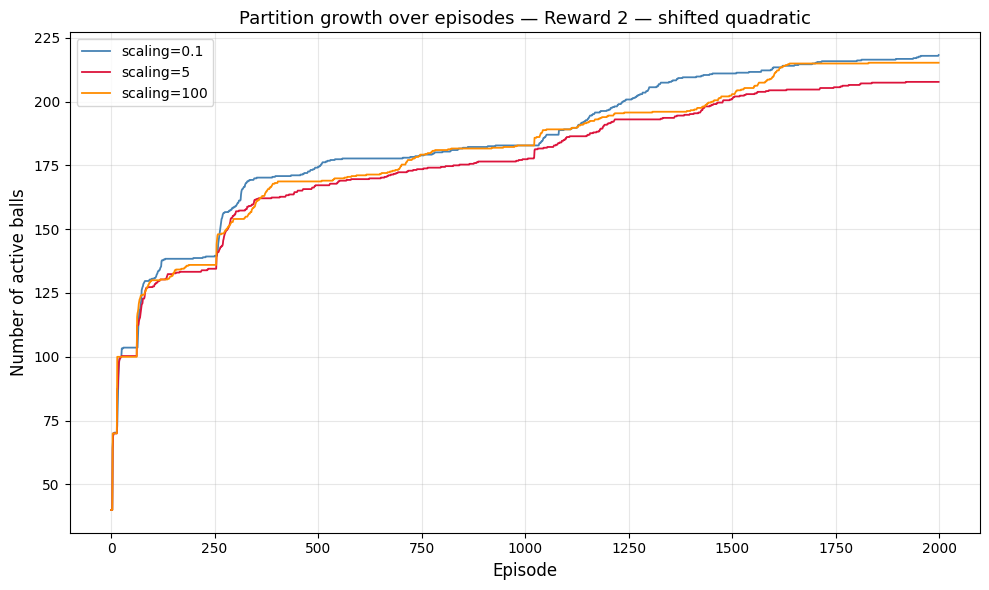

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r2:
    ax.plot(results_chosen_r2[f'scaling={s}']['arms'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Number of active balls', fontsize=12)
ax.set_title('Partition growth over episodes — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


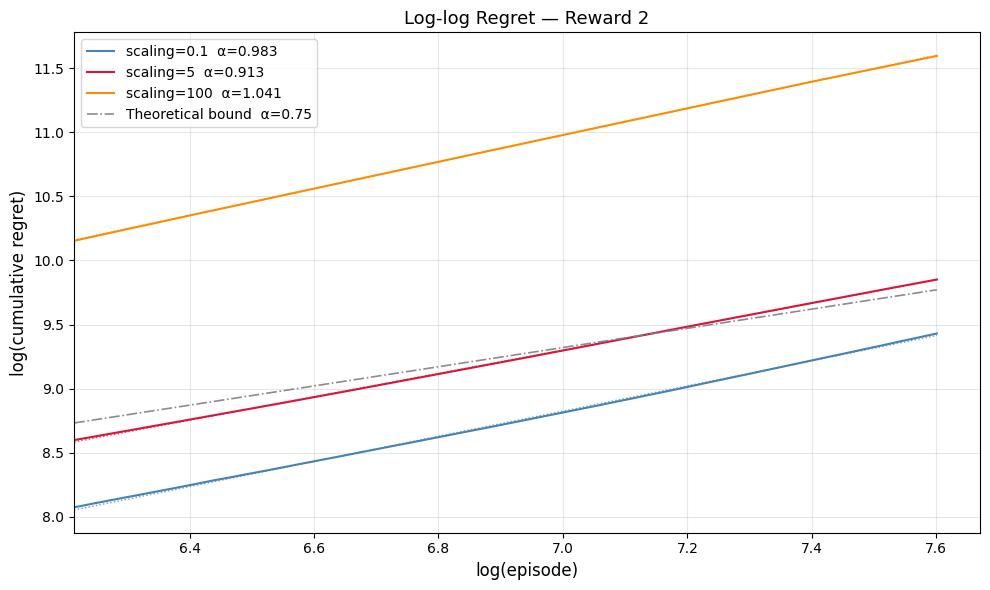

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in chosen_scalings_r2:
    vpi     = results_chosen_r2[f'scaling={s}']['vpi']
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R2 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.5, color=COLOURS[s], label=f'scaling={s}  α={slope:.3f}')
    ax.plot(lx, slope*lx + intercept, lw=1.0, color=COLOURS[s], ls=':', alpha=0.8)

# Theoretical worst-case bound α=0.75 anchored through midpoint of best curve
_best_vpi = results_chosen_r2['scaling=5']['vpi']
_eps      = np.arange(1, len(_best_vpi) + 1)
_cum      = np.cumsum(np.maximum(V_STAR_R2 - _best_vpi, 0.0))
_mask     = (_eps >= 500) & (_cum > 0)
_mid      = len(_eps[_mask]) // 2
_th_ic    = np.log(max(_cum[_mask][_mid], 1e-8)) - 0.75 * np.log(_eps[_mask][_mid])
_lx_th    = np.array([np.log(500), np.log(len(_best_vpi))])
ax.plot(_lx_th, 0.75*_lx_th + _th_ic, lw=1.2, color='gray', ls='-.', alpha=0.9,
        label='Theoretical bound  α=0.75')

ax.set_xlim(left=np.log(500))
ax.set_xlabel('log(episode)', fontsize=12)
ax.set_ylabel('log(cumulative regret)', fontsize=12)
ax.set_title('Log-log Regret — Reward 2', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 scaling  alpha  r_squared
    0.01 0.9944     0.9996
    0.05 0.9957     0.9996
    0.10 0.9956     0.9995
    0.50 0.9218     0.9997
    1.00 0.7503     0.9995
    5.00 0.9185     0.9999
   10.00 0.9201     1.0000
   50.00 0.9869     1.0000
  100.00 1.0410     1.0000
  500.00 1.0661     1.0000


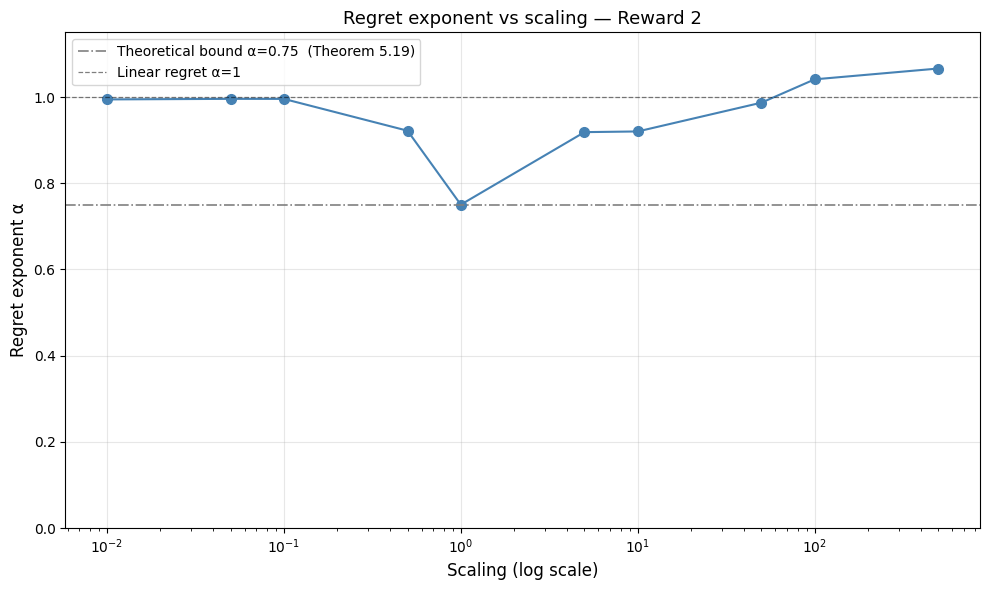

In [33]:
slopes_r2, regret_r2 = compute_regret_slopes(results_sweep_r2, scalings_r2, V_STAR_R2)
print(slopes_r2.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(slopes_r2['scaling'], slopes_r2['alpha'], marker='o', color='steelblue', lw=1.5, ms=7)
ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75  (Theorem 5.19)')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret exponent vs scaling — Reward 2', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reward 3 — quartic

In [35]:
importlib.reload(c)

cfg_r3 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quartic,
)
solver_r3 = c.BellmanSolverScalar(cfg_r3, n_state=201, n_action=201, n_quad=41)
solver_r3.solve()
V_STAR_R3 = solver_r3.get_value(cfg_r3.starting_state)
print(f'V*(x0) = {V_STAR_R3:.4f}  (expected ≈ 0.0)')


V*(x0) = 0.0244  (expected ≈ 0.0)


In [36]:
scalings_r3 = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in scalings_r3
]
results_sweep_r3 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.01 ---
    Done. Final mean VPI: -44.845

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -42.808

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -42.317

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -35.778

--- Running: scaling=1 ---
    Done. Final mean VPI: -30.102

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.347

--- Running: scaling=10 ---
    Done. Final mean VPI: -4.826

--- Running: scaling=50 ---
    Done. Final mean VPI: -29.690

--- Running: scaling=100 ---
    Done. Final mean VPI: -66.481

--- Running: scaling=500 ---
    Done. Final mean VPI: -217.952


In [38]:
summary_r3 = []
for s in scalings_r3:
    label = f'scaling={s}'
    vpi  = results_sweep_r3[label]['vpi']
    arms = results_sweep_r3[label]['arms']
    summary_r3.append({
        'scaling': s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })
summary_df_r3 = pd.DataFrame(summary_r3)
summary_df_r3


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-111312.996928,-44.844738,217.9,217.900
1,0.05,-107486.815318,-42.807951,217.9,217.900
2,0.10,-106767.292293,-42.316505,217.9,217.780
3,0.50,-95761.580945,-35.777972,218.8,218.533
4,1.00,-83849.438096,-30.102005,218.5,218.500
5,5.00,-36699.744962,-9.346509,220.0,219.022
6,10.00,-27931.819009,-4.826417,211.9,210.037
7,50.00,-87941.886820,-29.689632,211.3,211.300
8,100.00,-178209.057196,-66.481312,216.1,215.623
9,500.00,-407223.499634,-217.951798,217.0,217.000


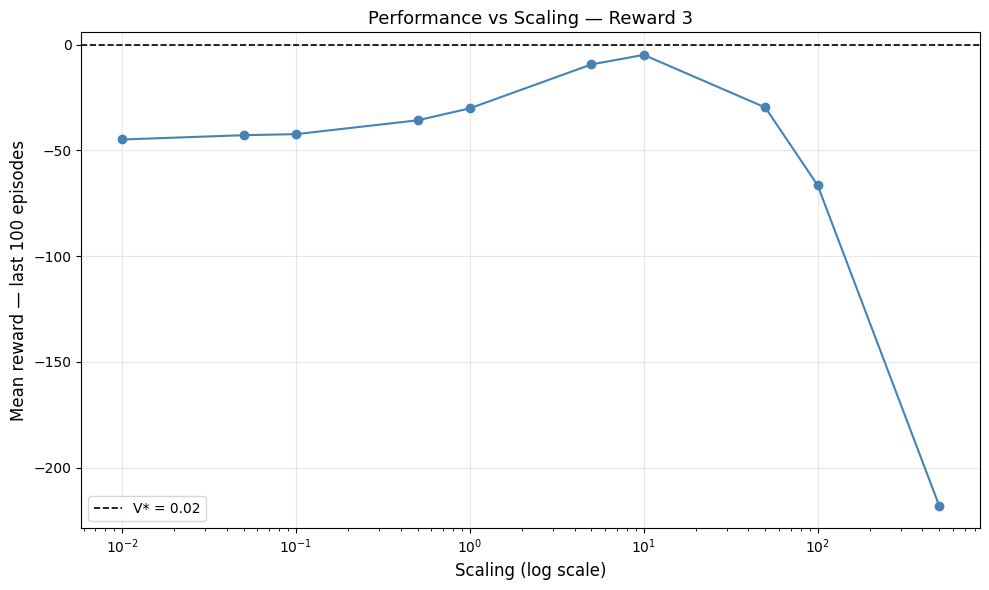

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r3['scaling'], summary_df_r3['late_mean_reward'], marker='o', color='steelblue', lw=1.5)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs Scaling — Reward 3', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_scaling_3.png', dpi=150, bbox_inches='tight')
plt.show()


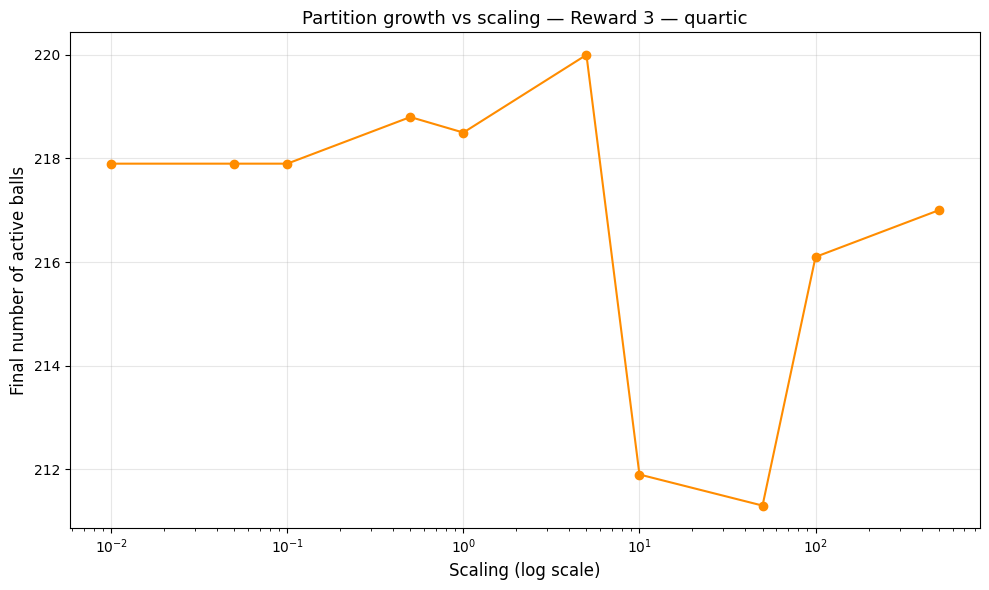

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r3['scaling'], summary_df_r3['final_arms'], marker='o', color='darkorange', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Final number of active balls', fontsize=12)
ax.set_title('Partition growth vs scaling — Reward 3 — quartic', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


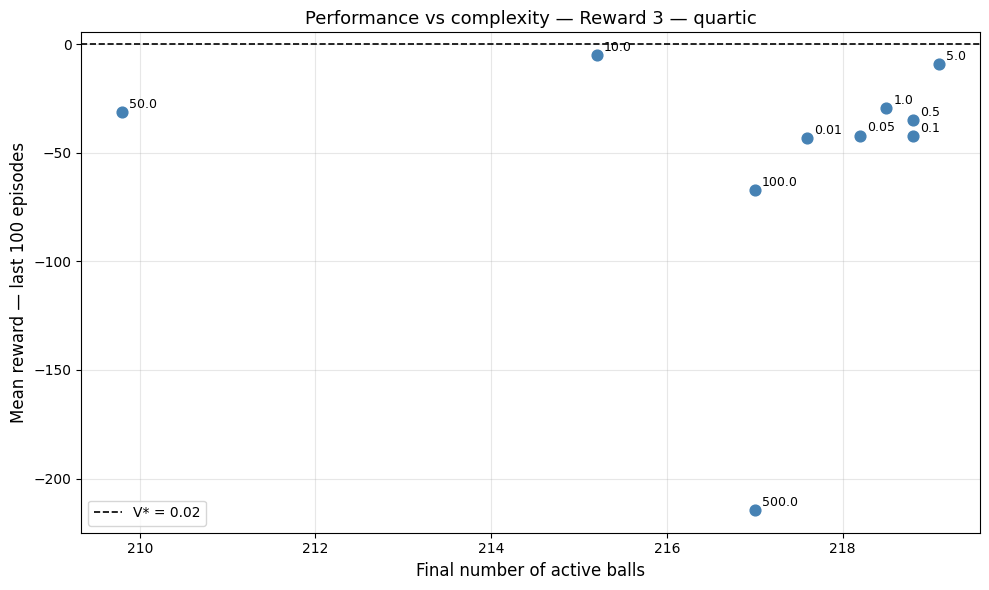

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary_df_r3['final_arms'], summary_df_r3['late_mean_reward'], color='steelblue', s=60)
for _, row in summary_df_r3.iterrows():
    ax.annotate(str(row['scaling']), (row['final_arms'], row['late_mean_reward']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xlabel('Final number of active balls', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs complexity — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [41]:
chosen_scalings_r3 = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in chosen_scalings_r3
]
results_chosen_r3 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.1 ---
    Done. Final mean VPI: -42.841

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.644

--- Running: scaling=100 ---
    Done. Final mean VPI: -68.238


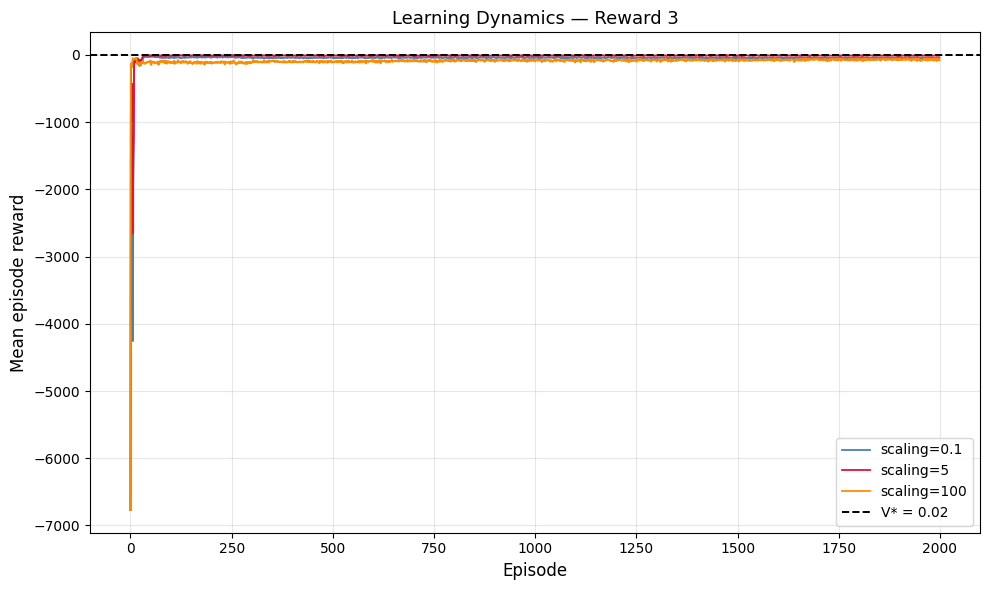

In [55]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r3:
    ax.plot(results_chosen_r3[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning Dynamics — Reward 3', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Learning_dynamics_3.png', dpi=150, bbox_inches='tight')
plt.show()


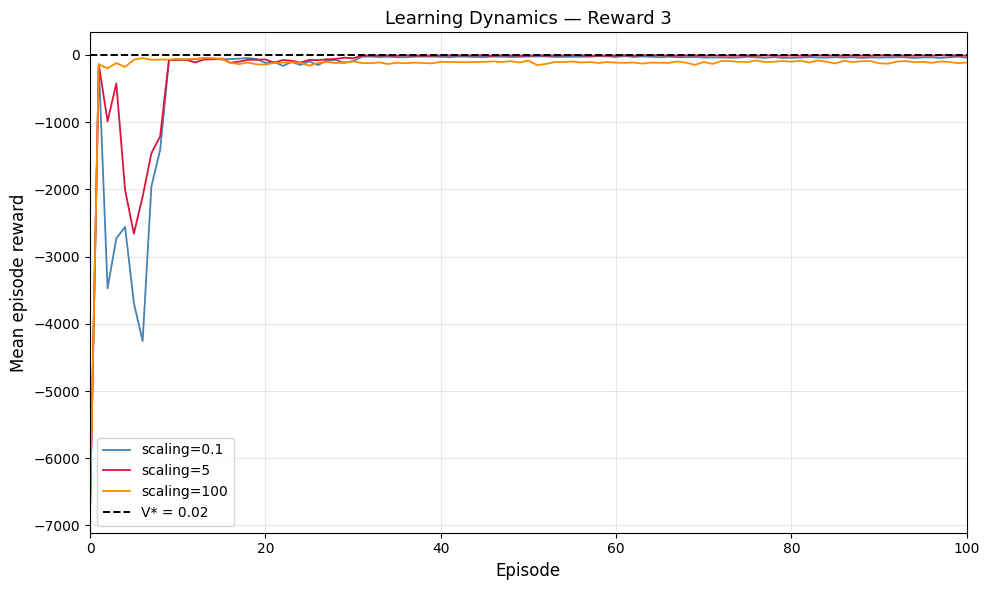

In [62]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r3:
    ax.plot(results_chosen_r3[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xlim(0, 100)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning Dynamics — Reward 3', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Learning_dynamics_3_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

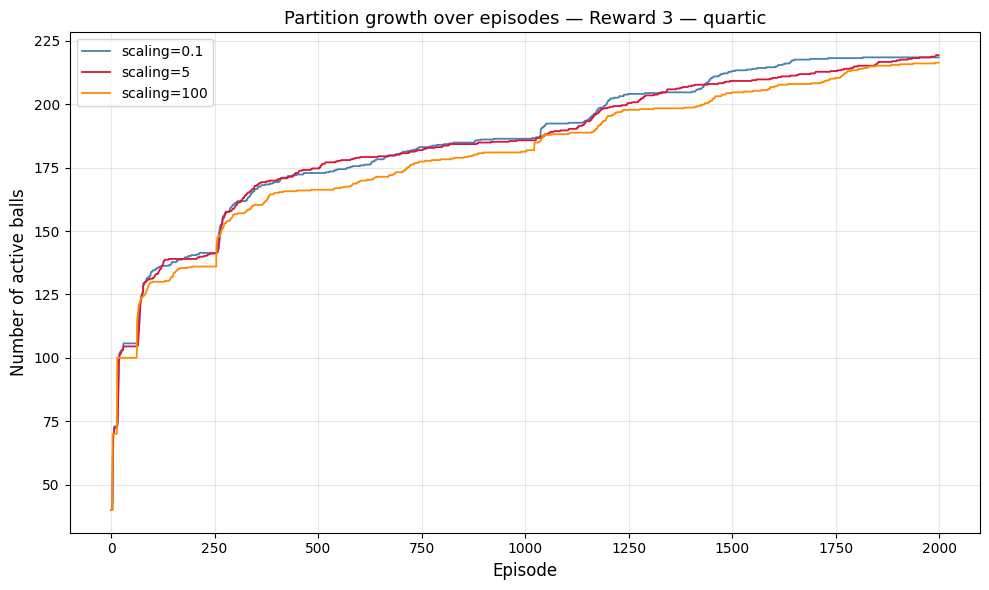

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r3:
    ax.plot(results_chosen_r3[f'scaling={s}']['arms'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Number of active balls', fontsize=12)
ax.set_title('Partition growth over episodes — Reward 3', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


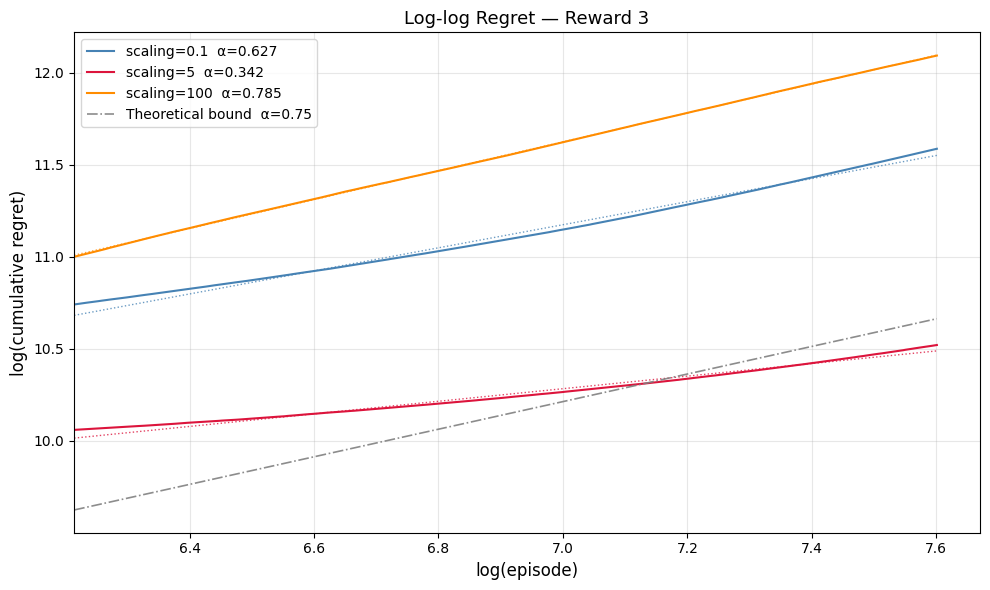

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in chosen_scalings_r3:
    vpi     = results_chosen_r3[f'scaling={s}']['vpi']
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R3 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.5, color=COLOURS[s], label=f'scaling={s}  α={slope:.3f}')
    ax.plot(lx, slope*lx + intercept, lw=1.0, color=COLOURS[s], ls=':', alpha=0.8)

# Theoretical worst-case bound α=0.75 anchored through midpoint of best curve
_best_vpi = results_chosen_r3['scaling=5']['vpi']
_eps      = np.arange(1, len(_best_vpi) + 1)
_cum      = np.cumsum(np.maximum(V_STAR_R3 - _best_vpi, 0.0))
_mask     = (_eps >= 500) & (_cum > 0)
_mid      = len(_eps[_mask]) // 2
_th_ic    = np.log(max(_cum[_mask][_mid], 1e-8)) - 0.75 * np.log(_eps[_mask][_mid])
_lx_th    = np.array([np.log(500), np.log(len(_best_vpi))])
ax.plot(_lx_th, 0.75*_lx_th + _th_ic, lw=1.2, color='gray', ls='-.', alpha=0.9,
        label='Theoretical bound  α=0.75')

ax.set_xlim(left=np.log(500))
ax.set_xlabel('log(episode)', fontsize=12)
ax.set_ylabel('log(cumulative regret)', fontsize=12)
ax.set_title('Log-log Regret — Reward 3', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 scaling  alpha  r_squared
    0.01 0.6416     0.9936
    0.05 0.6239     0.9921
    0.10 0.6232     0.9927
    0.50 0.5818     0.9913
    1.00 0.5351     0.9891
    5.00 0.3349     0.9850
   10.00 0.2363     0.9839
   50.00 0.6360     0.9995
  100.00 0.7772     0.9999
  500.00 1.0654     1.0000


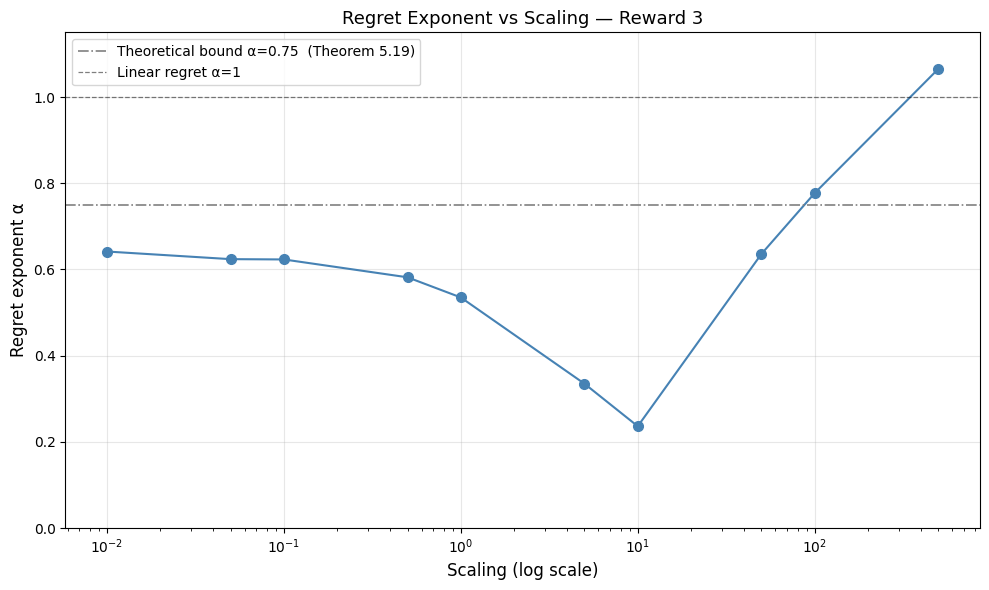

In [44]:
slopes_r3, regret_r3 = compute_regret_slopes(results_sweep_r3, scalings_r3, V_STAR_R3)
print(slopes_r3.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(slopes_r3['scaling'], slopes_r3['alpha'], marker='o', color='steelblue', lw=1.5, ms=7)
ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75  (Theorem 5.19)')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret Exponent vs Scaling — Reward 3', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Cross-reward comparison

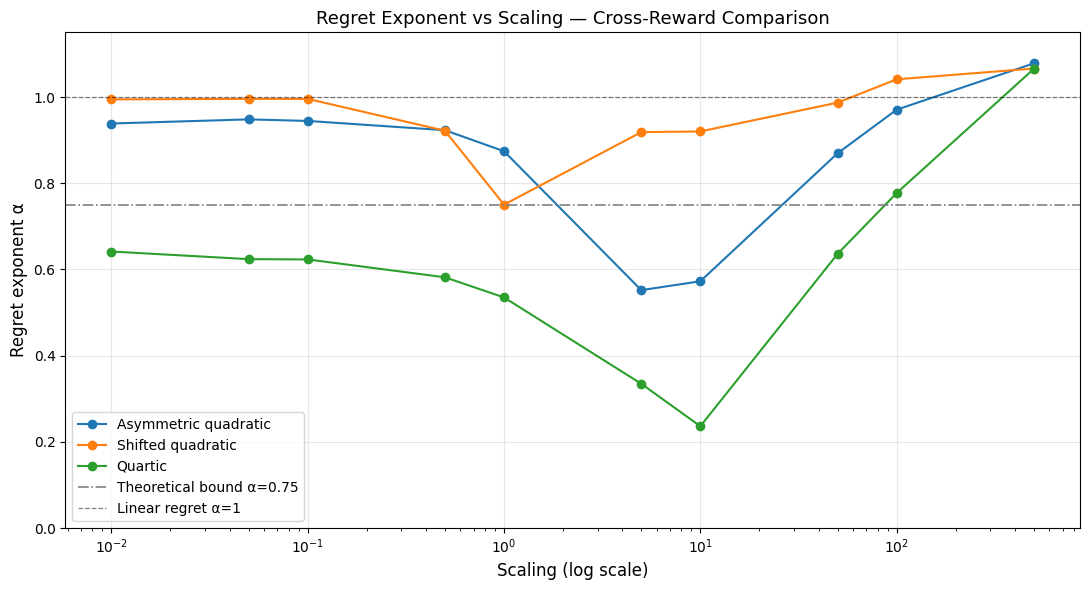

In [52]:
fig, ax = plt.subplots(figsize=(11, 6))

for slopes, label, colour in [
    (slopes_r1, 'Asymmetric quadratic', 'steelblue'),
    (slopes_r2, 'Shifted quadratic',    'crimson'),
    (slopes_r3, 'Quartic',              'darkorange'),
]:
    ax.plot(slopes['scaling'], slopes['alpha'], marker='o', lw=1.5, label=label)

ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret Exponent vs Scaling — Cross-Reward Comparison', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_reward_regret_exponent.png', dpi=150, bbox_inches='tight')
plt.show()


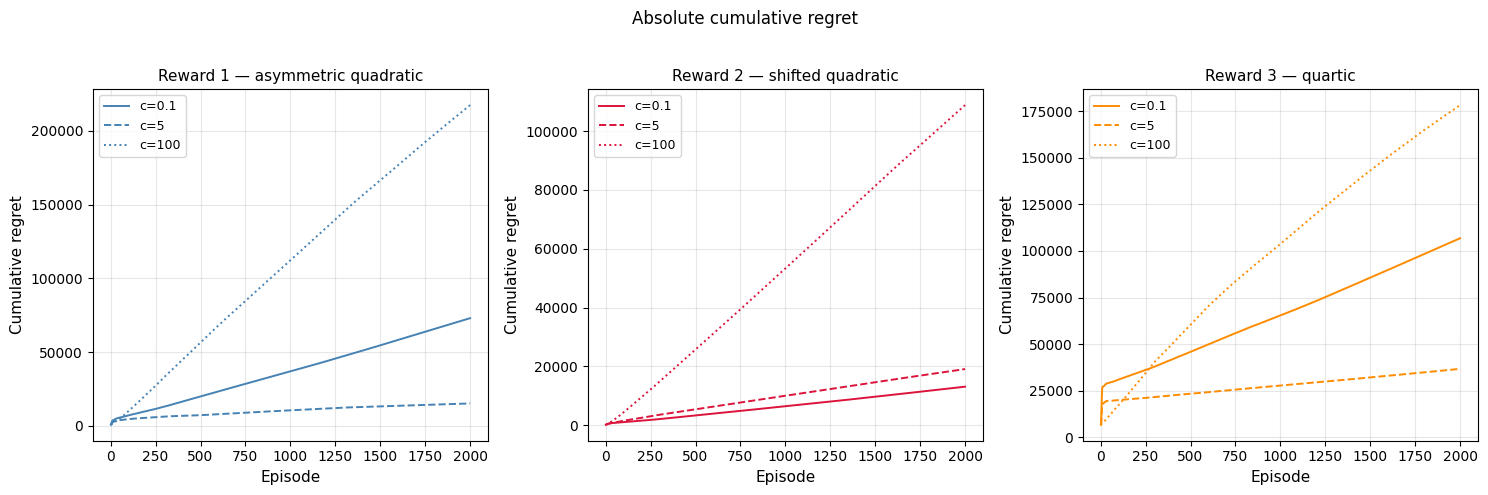

In [47]:
# Cross-reward: absolute cumulative regret for representative scalings
# Shows that lower alpha for R3 is not because R3 has lower absolute regret —
# at bad scalings R3 accumulates MORE regret, confirming quartic punishes harder

CHOSEN_C = [0.1, 5, 100]
eps = np.arange(1, 2001)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

configs_plot = [
    ("Reward 1 — asymmetric quadratic", regret_r1, "steelblue"),
    ("Reward 2 — shifted quadratic",    regret_r2, "crimson"),
    ("Reward 3 — quartic",              regret_r3, "darkorange"),
]

for ax, (title, regret_dict, colour) in zip(axes, configs_plot):
    for s, ls in zip(CHOSEN_C, ["-", "--", ":"]):
        label = f"scaling={s}"
        ax.plot(eps, regret_dict[label], lw=1.4, ls=ls,
                color=colour, label=f"c={s}")
    ax.set_xlabel("Episode", fontsize=11)
    ax.set_ylabel("Cumulative regret", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Absolute cumulative regret\n",
    fontsize=12
)
plt.tight_layout()
plt.show()

In [51]:
# ── Cross-reward summary table ─────────────────────────────────────────────
a_r1 = dict(zip(slopes_r1["scaling"], slopes_r1["alpha"]))
a_r2 = dict(zip(slopes_r2["scaling"], slopes_r2["alpha"]))
a_r3 = dict(zip(slopes_r3["scaling"], slopes_r3["alpha"]))

rows = []
for s in scalings_r1:
    label = f"scaling={s}"
    rows.append({
        "Scaling":    round(float(s), 2),
        "R1  α":      round(a_r1[s], 3),
        "R1  Regret": int(round(float(regret_r1[label][-1]))),
        "R2  α":      round(a_r2[s], 3),
        "R2  Regret": int(round(float(regret_r2[label][-1]))),
        "R3  α":      round(a_r3[s], 3),
        "R3  Regret": int(round(float(regret_r3[label][-1]))),
    })

table = pd.DataFrame(rows)

alpha_cols  = ["R1  α", "R2  α", "R3  α"]
regret_cols = ["R1  Regret", "R2  Regret", "R3  Regret"]

def style_alpha(val):
    if not isinstance(val, float):
        return "color: #111111"
    if val > 1.0:
        return "background-color: #f4a0a0; color: #111111; font-weight: bold"
    if val < 0.75:
        return "background-color: #a8d8a8; color: #111111; font-weight: bold"
    return "background-color: #fde9a2; color: #111111"

display(
    table.style
         .map(style_alpha, subset=alpha_cols)
         .map(lambda _: "color: #111111", subset=["Scaling"] + regret_cols)
         .format({c: "{:.3f}" for c in alpha_cols})
         .format({c: "{:,.0f}" for c in regret_cols})
         .format({"Scaling": "{:.2f}"})
         .set_table_styles([
             {"selector": "th",
              "props": [("background-color", "#e8e8e8"),
                        ("color", "#111111"),
                        ("font-weight", "bold"),
                        ("border", "1px solid #cccccc"),
                        ("padding", "6px 12px")]},
             {"selector": "td",
              "props": [("border", "1px solid #dddddd"),
                        ("padding", "5px 12px")]},
             {"selector": "tr:nth-child(even) td",
              "props": [("background-color", "#f2f2f2"),
                        ("color", "#111111")]},
             {"selector": "tr:nth-child(odd) td",
              "props": [("background-color", "#ffffff"),
                        ("color", "#111111")]},
             {"selector": "caption",
              "props": [("color", "#111111"),
                        ("font-size", "0.9em"),
                        ("padding-top", "8px")]},
         ])
         .set_caption(
             "Regret exponent α and total cumulative regret over K = 2000 episodes. "
             "Green: α < 0.75 (below theoretical bound).  "
             "Amber: 0.75 ≤ α < 1.0.  Red: α ≥ 1.0 (super-linear)."
         )
         .hide(axis="index")
)

Scaling,R1 α,R1 Regret,R2 α,R2 Regret,R3 α,R3 Regret
0.01,0.939000,72730,0.994000,14651,0.642000,111362
0.05,0.948000,75231,0.996000,13810,0.624000,107536
0.10,0.945000,72936,0.996000,13095,0.623000,106816
0.50,0.923000,59338,0.922000,9590,0.582000,95810
1.00,0.874000,46908,0.750000,6274,0.535000,83898
5.00,0.552000,15115,0.918000,19087,0.335000,36749
10.00,0.573000,13868,0.920000,35655,0.236000,27981
50.00,0.869000,135942,0.987000,85638,0.636000,87991
100.00,0.971000,217463,1.041000,108872,0.777000,178258
500.00,1.078000,281226,1.066000,120294,1.065000,407272
